In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

save_path = "outputs/dnn/"
img_path = "images/thermal_image_2.png"
img = cv2.imread(img_path)
if img is None:
    raise RuntimeError("Image could not be open")

blob = cv2.dnn.blobFromImage(
    img,
    scalefactor=1.0 / 255.0,
    size=(224, 224),
    mean=(0, 0, 0),
    swapRB=True,
    crop=False
)

print("Original image shape: ", img.shape)
print("Blob shape: ", blob.shape)
print("Original image Dtype: ", img.dtype)
print("Blob Dtype: ", blob.dtype)
print("Original image max: ", np.max(img))
print("Blob max: ", np.max(blob))
print("Original image min: ", np.min(img))
print("Blob min: ", np.min(blob))

def _convert_from_bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def _convert_from_bgr_to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def _show_bgr_image(img):
    plt.imshow(_convert_from_bgr_to_rgb(img), vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

Original image shape:  (895, 1192, 3)
Blob shape:  (1, 3, 224, 224)
Original image Dtype:  uint8
Blob Dtype:  float32
Original image max:  235
Blob max:  0.9137255
Original image min:  0
Blob min:  0.043137256


OpenCV DNN does not feed your normal image directly into the model. It converts it into a blob.

A blob is a prepared tensor with shape usually like:
N x C x H x W

N = batch size
C = channels
H = height
W = width

## Exercise 2 — Visualize what preprocessing did

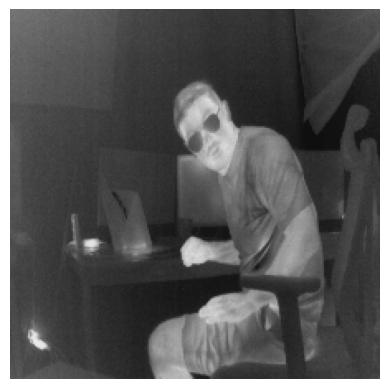

True

In [2]:
# blob shape: 1 x 3 x 224 x 224
blob_img = blob[0]              # 3 x 224 x 224
blob_img = blob_img.transpose(1, 2, 0)  # 224 x 224 x 3

# Convert RGB back to BGR for OpenCV display/save because swapRB=True was used
blob_img_bgr = cv2.cvtColor(blob_img, cv2.COLOR_RGB2BGR)

# Convert from 0-1 float to 0-255 uint8
display_img = (blob_img_bgr * 255).astype("uint8")

_show_bgr_image(blob_img_bgr)

cv2.imwrite(save_path + "blob_visualized.jpg", display_img)

In [3]:
model_path = "models/mobilenetv2.onnx"
classes_path = "models/imagenet_classes.txt"
image_path = "images/frog.jpg"

img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(image_path)

with open(classes_path, "r") as f:
    classes = [line.strip() for line in f.readlines()]

net = cv2.dnn.readNetFromONNX(model_path)

blob = cv2.dnn.blobFromImage(
    img,
    scalefactor=1.0 / 255.0,
    size=(224, 224),
    mean=(0, 0, 0),
    swapRB=True,
    crop=False
)

net.setInput(blob)

output = net.forward()

print("Output shape:", output.shape)
print(output)

Output shape: (1, 1000)
[[ 4.76675129e+00  6.72738504e+00  1.49115753e+00  3.33512831e+00
   4.18810892e+00  4.49938202e+00  3.51740146e+00 -2.60175896e+00
  -1.94947314e+00 -2.35992718e+00 -8.94997597e-01  1.22211766e+00
  -1.20129716e+00  9.84547496e-01 -7.41455555e-02 -3.82200599e-01
  -8.00923347e-01 -5.16914368e-01 -4.08655405e-01 -2.95244288e+00
  -1.60204148e+00 -5.36493242e-01 -1.35562867e-01  6.15294933e-01
  -1.44033027e+00  5.21719599e+00  8.12568188e+00  7.44189930e+00
   4.02536583e+00  3.99560189e+00  1.11453552e+01  1.39320526e+01
   1.26536465e+01  1.97610390e+00  1.76989138e+00  2.43664074e+00
   4.62651396e+00  3.41478133e+00  9.54748058e+00  4.50680017e+00
   8.24087715e+00  3.68803144e+00  7.35336971e+00  4.75272799e+00
   2.78364134e+00  2.10986042e+00  7.99702168e+00  1.09514303e+01
   2.51257563e+00  4.75573444e+00  3.29978848e+00  4.12210369e+00
   1.26068437e+00  8.37266028e-01  3.33693743e-01  2.90156746e+00
   1.81476688e+00  1.20000052e+00  5.10102272e+00  1

The output is usually a list of class scores.
Get the top prediction:

In [4]:
scores = output[0]

class_id = int(np.argmax(scores))
confidence = float(scores[class_id])

label = classes[class_id] if class_id < len(classes) else str(class_id)

print("Prediction: ", label)
print("Confidence: ", confidence)

Prediction:  tree frog
Confidence:  13.932052612304688


Do not only look at the best class. Print the top 5.

In [5]:
top5_ids = np.argsort(scores)[-5:][::-1]

for id in top5_ids:
    print(f"Label: {classes[id]} with a confidence of {scores[id]}")

Label: tree frog with a confidence of 13.932052612304688
Label: tailed frog with a confidence of 12.653646469116211
Label: bullfrog with a confidence of 11.145355224609375
Label: African chameleon with a confidence of 10.951430320739746
Label: banded gecko with a confidence of 9.547480583190918


## Object detection with OpenCV DNN
### Goal
Do not blindly copy detector code.
First inspect what your model actually outputs.
This is important because YOLOv5, YOLOv8, SSD, and other models can have different output layouts.

### The general detection pipeline is:
* load model
* load image
* create blob
* forward pass
* parse boxes/classes/confidences
* filter by confidence
* apply NMS
* draw results

In [6]:
# Lets first inspect the model input shape to makesure that we pass the right dimmensions
import onnx

model = onnx.load("models/detector.onnx")

for input_tensor in model.graph.input:
    print("Input name: ", input_tensor.name)

    dims = []
    for dim in input_tensor.type.tensor_type.shape.dim:
        if dim.dim_value:
            dims.append(dim.dim_value)
        else:
            dims.append(dim.dim_param)

    print("Input shape: ", dims)


Input name:  input_1:0
Input shape:  ['unk__2104', 416, 416, 3]


It shows that the model need to receive the blob in the NHWC format (channels at the end) and the image must be resized to 416x416

In [8]:
# Load the model
net = cv2.dnn.readNetFromONNX("models/detector.onnx")

# Load the image
img_path = "images/frog.jpg"
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError("images/input.jpg not found")

# Create a blob
blob = cv2.dnn.blobFromImage(
    img,
    scalefactor=1.0 / 255.0,
    size=(416, 416),
    mean=(0, 0, 0),
    swapRB=True,
    crop=False
)

# This model expects NHWC and no NCHW
blob_nhwc = np.transpose(blob, (0, 2, 3, 1))

# Forward pass
net.setInput(blob_nhwc)

# to get all the outputs (different grids)
out_names = net.getUnconnectedOutLayersNames()
print(out_names) 
outputs = net.forward(out_names)

# Analyse results
print(type(outputs))

if isinstance(outputs, tuple):
    for i, out in enumerate(outputs):
        print(i, out.shape)
else:
    print(outputs.shape)

('Identity:0', 'Identity_1:0', 'Identity_2:0')
<class 'tuple'>
0 (1, 52, 52, 3, 85)
1 (1, 26, 26, 3, 85)
2 (1, 13, 13, 3, 85)


In [18]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# this anchors are documented in the model, their goal is to detect objects of different shapes in each grid cell
anchors_per_scale = {
    52: [(12, 16), (19, 36), (40, 28)],
    26: [(36, 75), (76, 55), (72, 146)],
    13: [(142, 110), (192, 243), (459, 401)],
}

# At the end we want the box info, the score and the class id
all_boxes, all_scores, all_class_ids = [], [], []

for output in outputs:
    grid_size = output.shape[1] # 52, 26 or 13
    stride = 416 / grid_size # 8, 16 or 32
    anchors = anchors_per_scale[grid_size]

    # start loop over the grid
    for row in range(grid_size):
        for col in range(grid_size):
            # check every anchor 
            for a in range(3):
                tx, ty, tw, th, to, *class_scores = output[0, row, col, a] #bounding box, objectness, and class scores

                # get real values of bounding box using stride of gride and current measures of anchor
                bx = (sigmoid(tx) + col) * stride
                by = (sigmoid(ty) + row) * stride
                bw = np.exp(tw) * anchors[a][0]
                bh = np.exp(th) * anchors[a][1]

                objectness = sigmoid(to)
                class_probs = sigmoid(np.array(class_scores))
                class_id = int(np.argmax(class_probs)) #get the index of the class with highest prob
                confidence = float(objectness * class_probs[class_id]) # the full score includes the prob of object presence

                # with the same index save bounding box, confidence and class id if confidence is higher enough
                if confidence > 0.5:
                    x1 = bx - bw / 2
                    y1 = by - bh / 2
                    all_boxes.append([x1, y1, bw, bh])
                    all_scores.append(confidence)
                    all_class_ids.append(class_id)

print("Candidate boxes before NMS:", len(all_boxes))

Candidate boxes before NMS: 4


We can now apply NMS to remove overlaping boxes and set a threshold for the confidence

In [19]:
indices = cv2.dnn.NMSBoxes(all_boxes, all_scores, score_threshold=0.5, nms_threshold=0.4)
print(indices[:5])

[3]


Now it is necessary to rescale bounding boxes to the original image size

Coco classes:  ['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


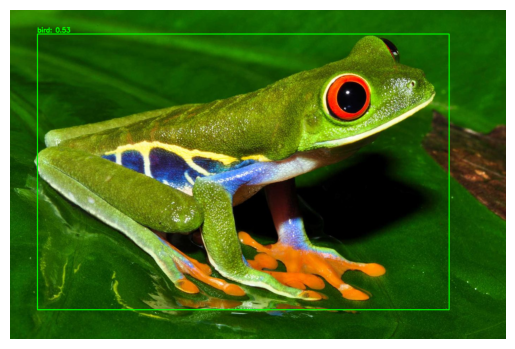

True

In [22]:
original_height, original_width, _ = img.shape
scale_x = original_width / 416
scale_y = original_height / 416

classes_path = "models/coco_classes.txt"
with open(classes_path, "r") as f:
    coco_classes = [line.strip() for line in f.readlines()]

print("Coco classes: ", coco_classes)

output = img.copy()

for i in indices:
    x, y, w, h = all_boxes[i]
    class_id = all_class_ids[i]
    score = all_scores[i]

    # map from 416x416 space back to the original image
    x = int(x * scale_x)
    y = int(y * scale_y)
    w = int(w * scale_x)
    h = int(h * scale_y)

    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

    label = f"{coco_classes[class_id] if class_id < len(coco_classes) else str(class_id)}: {score:.2f}"
    cv2.putText(
        output, 
        label, 
        (x, max(y - 5, 0)),
        cv2.FONT_HERSHEY_SIMPLEX, 
        0.6, 
        (0, 255, 0), 
        2
    )

_show_bgr_image(output)
cv2.imwrite(save_path + "yolov4_detections.jpg", output)

## Face detection

In [38]:
model = "models/res10_300x300_ssd_iter_140000.caffemodel"
config = "models/deploy.prototxt"

net = cv2.dnn.readNetFromCaffe(config, model)

img = cv2.imread("images/face_2.png")
if img is None:
    raise FileNotFoundError("image not found")

h, w = img.shape[:2]

print("height: ", h, "weight: ", w)

blob = cv2.dnn.blobFromImage(
    img,
    scalefactor=1.0,        # no pixel value scaling (keep 0-255 range)
    size=(300, 300),        # model input size
    mean=(104.0, 177.0, 123.0),   # BGR mean subtraction (from training dataset)
    swapRB=False,           # input is already BGR, model was trained on BGR
    crop=False
)

net.setInput(blob)
detections = net.forward()

print("Detections shape:", detections.shape)

height:  482 weight:  335
Detections shape: (1, 1, 200, 7)


### Output shape: (1, 1, 200, 7)

- **1** — batch size (one image)
- **1** — structural artifact of the Caffe SSD output format, always 1
- **200** — number of candidate detections (always 200 regardless of how many faces are in the image; most will have very low confidence)
- **7** — values per detection:

| Index | Value | Meaning |
|-------|-------|---------|
| 0 | `image_id` | index of the image in the batch (always 0 for single image) |
| 1 | `class_id` | detected class (always 1 — this model only detects faces) |
| 2 | `confidence` | detection score between 0 and 1 |
| 3 | `x1` | left edge of box, normalized [0, 1] |
| 4 | `y1` | top edge of box, normalized [0, 1] |
| 5 | `x2` | right edge of box, normalized [0, 1] |
| 6 | `y2` | bottom edge of box, normalized [0, 1] |

Coordinates are **normalized** — multiply by the original image width/height to get pixel coordinates.

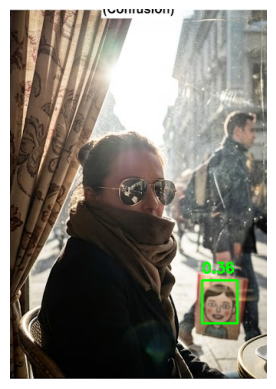

In [39]:
# Draw face detections

output = img.copy()

# check each of the 200 detections
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    
    # filter by confidence
    if confidence > 0.3:
        # box corners normalized so it multiplies by original dimensions to recover box useful box sizes
        box = detections[0, 0, i, 3:7] * [w, h, w, h]
        x1, y1, x2, y2 = box.astype("int")

        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(output, f"{confidence:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

cv2.imwrite(save_path + "dnn_face_detection_2.jpg", output)

_show_bgr_image(output)

## Run DNN face detector on video

In [43]:
import time

model = "models/res10_300x300_ssd_iter_140000.caffemodel"
config = "models/deploy.prototxt"
net = cv2.dnn.readNetFromCaffe(config, model)

cap = cv2.VideoCapture("videos/ia.mp4")

# Some parameters needed by the video writter
fps = cap.get(cv2.CAP_PROP_FPS)
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

if fps < 30:
    fps = 30

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    save_path + "face_detection_in_ia_video.mp4",
    fourcc,
    fps,
    (width, height),
    isColor=True
)

if not cap.isOpened():
    raise RuntimeError("Could not open video")

prev_time = time.time()
fps_smooth = 0

while True:

    ret, frame = cap.read()
    if not ret:
        break

    # start frame processing
    blob = cv2.dnn.blobFromImage(
        frame,
        scalefactor=1.0,
        size=(300, 300),
        mean=(104.0, 177.0, 123.0),
        swapRB=False,
        crop=False
    )

    net.setInput(blob)
    detections = net.forward()

    h, w = frame.shape[:2]
    output = frame.copy()

    for i in range(detections.shape[2]):

        if detections[0, 0, i, 2] > 0.4:
            box = detections[0, 0, 1, 3:7] * [w, h, w, h]
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(output, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    now = time.time()
    fps = 1.0 / (now - prev_time)
    prev_time = now
    fps_smooth = 0.9 * fps_smooth + 0.1 * fps if fps_smooth > 0 else fps
    cv2.putText(output, f"FPS: {fps_smooth:.1f}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
    writer.write(output)

cap.release()
writer.release()


## Try OpenCV DNN backends and targets

In [45]:
model = "models/res10_300x300_ssd_iter_140000.caffemodel"
config = "models/deploy.prototxt"
net = cv2.dnn.readNetFromCaffe(config, model)

try:
    net.setPreferableBackend(cv2.dnn.DNN_BACKEND_CUDA)
    net.setPreferableTarget(cv2.dnn.DNN_TARGET_CUDA)
    print("Using CUDA backend")
except Exception as e:
    print("CUDA backend not available, using CPU")
    net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
    net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Measuring inference time
img = cv2.imread("images/face_2.png")
if img is None:
    raise FileNotFoundError("image not found")

h, w = img.shape[:2]

print("height: ", h, "weight: ", w)

blob = cv2.dnn.blobFromImage(
    img,
    scalefactor=1.0,        # no pixel value scaling (keep 0-255 range)
    size=(300, 300),        # model input size
    mean=(104.0, 177.0, 123.0),   # BGR mean subtraction (from training dataset)
    swapRB=False,           # input is already BGR, model was trained on BGR
    crop=False
)

start_time = time.time()
net.setInput(blob)
detections = net.forward()
end = time.time()
inference_ms = (end - start_time) * 1000
print(f"Inference time: {inference_ms:.2f} ms")

Using CUDA backend
height:  482 weight:  335
Inference time: 77.03 ms


[ WARN:0@26527.997] global net_impl.cpp:178 setUpNet DNN module was not built with CUDA backend; switching to CPU
